In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\bhaga\python\PSCompPars_2026.08.08_04.23.14.csv",comment='#')

In [5]:
threshold = len(df) *0.5
df_clean = df.dropna(thresh=threshold, axis = 1)

key_cols = ['pl_orbper','pl_rade','pl_bmasse','st_teff','st_rad','st_mass']
key_cols = [c for c in key_cols if c in df_clean.columns]
for col in key_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean = df_clean.dropna(subset=['pl_name','disc_year'])
df_clean['disc_year'] = df_clean['disc_year'].astype(int)

print('Ready:', df_clean.shape )

Ready: (6336, 75)


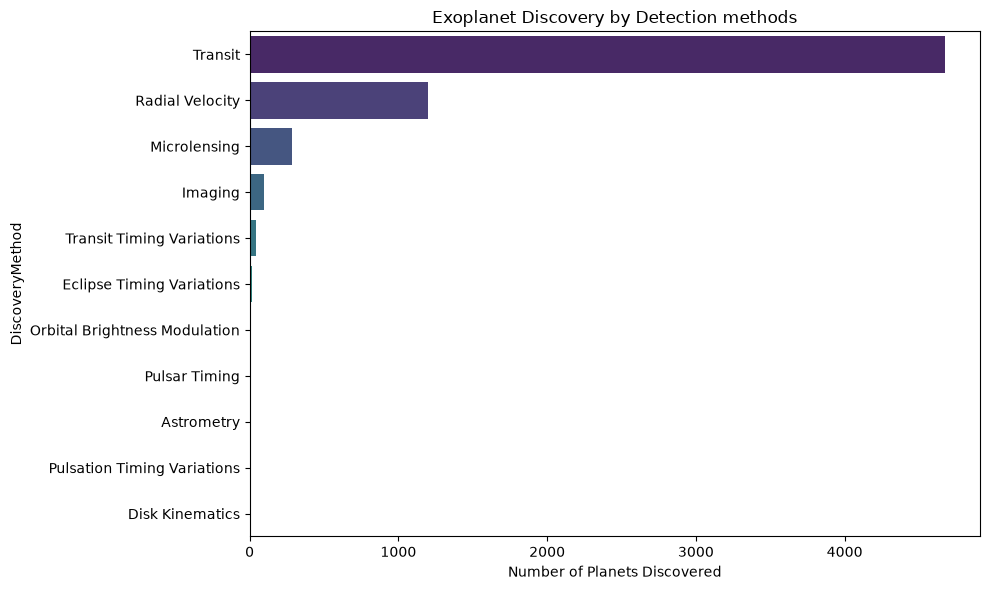

In [7]:
plt.figure(figsize=(10,6))
method_counts = df_clean['discoverymethod'].value_counts()
sns.barplot(x=method_counts.values, y=method_counts.index, hue= method_counts.index, palette='viridis',legend=False)
plt.xlabel('Number of Planets Discovered')
plt.ylabel('DiscoveryMethod')
plt.title('Exoplanet Discovery by Detection methods')
plt.tight_layout()
plt.show()

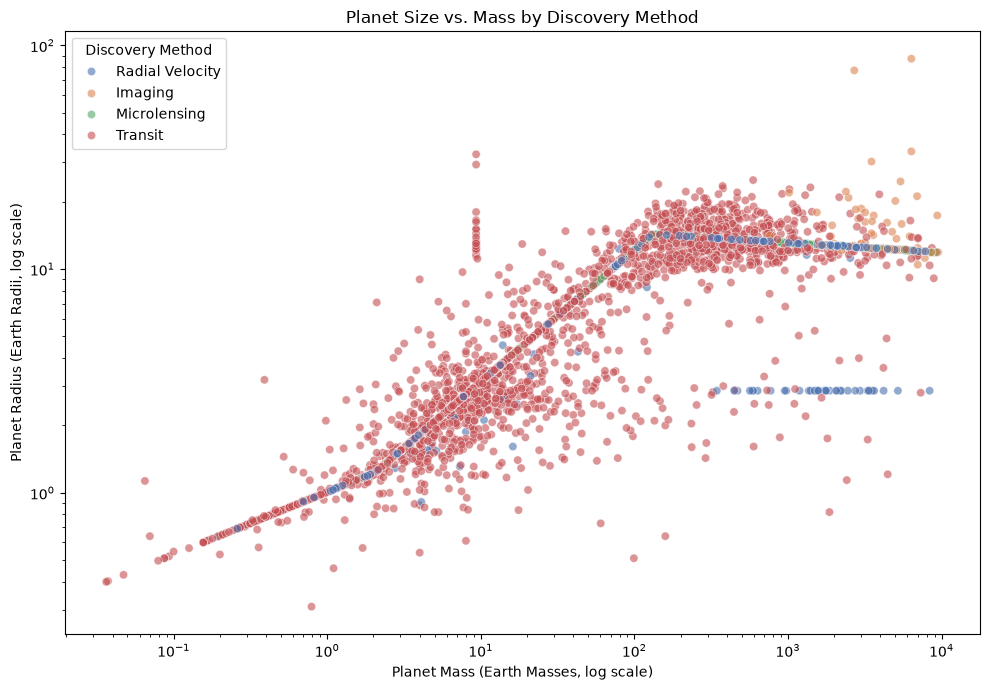

In [9]:
plt.figure(figsize=(10,7))
top_methods = df_clean['discoverymethod'].value_counts().nlargest(4).index
subset = df_clean[df_clean['discoverymethod'].isin(top_methods)]

sns.scatterplot(data=subset, x='pl_bmasse', y= 'pl_rade', hue= 'discoverymethod',alpha=0.6, palette='deep')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Planet Mass (Earth Masses, log scale)')
plt.ylabel('Planet Radius (Earth Radii, log scale)')
plt.title('Planet Size vs. Mass by Discovery Method')
plt.legend(title='Discovery Method')
plt.tight_layout()  
plt.show()

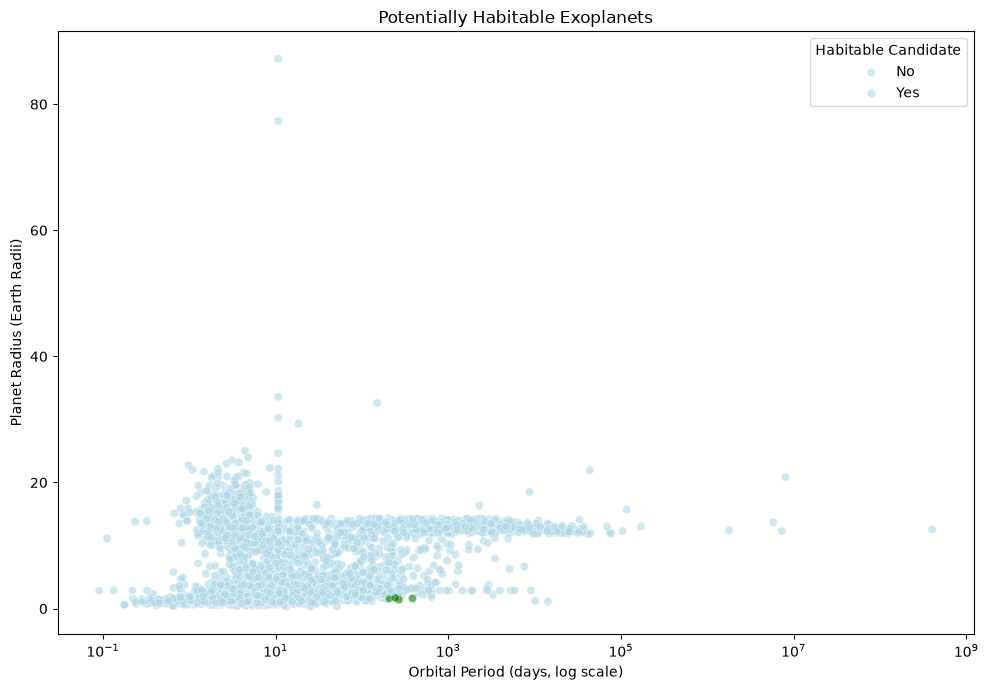

Number of potentially habitable candidates: 6


In [12]:
plt.figure(figsize=(10,7))
# Define a rough 'Earth like'filter:radius 0.5-2*Earth, orbital period 200-500 days(roughly in the habitable zone
df_clean['habitable_candidate'] = (df_clean['pl_rade'].between(0.5, 2)) & (df_clean['pl_orbper'].between(200, 500))

sns.scatterplot(data=df_clean, x='pl_orbper', y='pl_rade', hue='habitable_candidate', alpha=0.6, palette={True: 'green', False: 'lightblue'}, legend=True)
plt.xscale('log')
plt.xlabel('Orbital Period (days, log scale)')
plt.ylabel('Planet Radius (Earth Radii)')
plt.title('Potentially Habitable Exoplanets')
plt.legend(title='Habitable Candidate', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

print("Number of potentially habitable candidates:", df_clean['habitable_candidate'].sum())


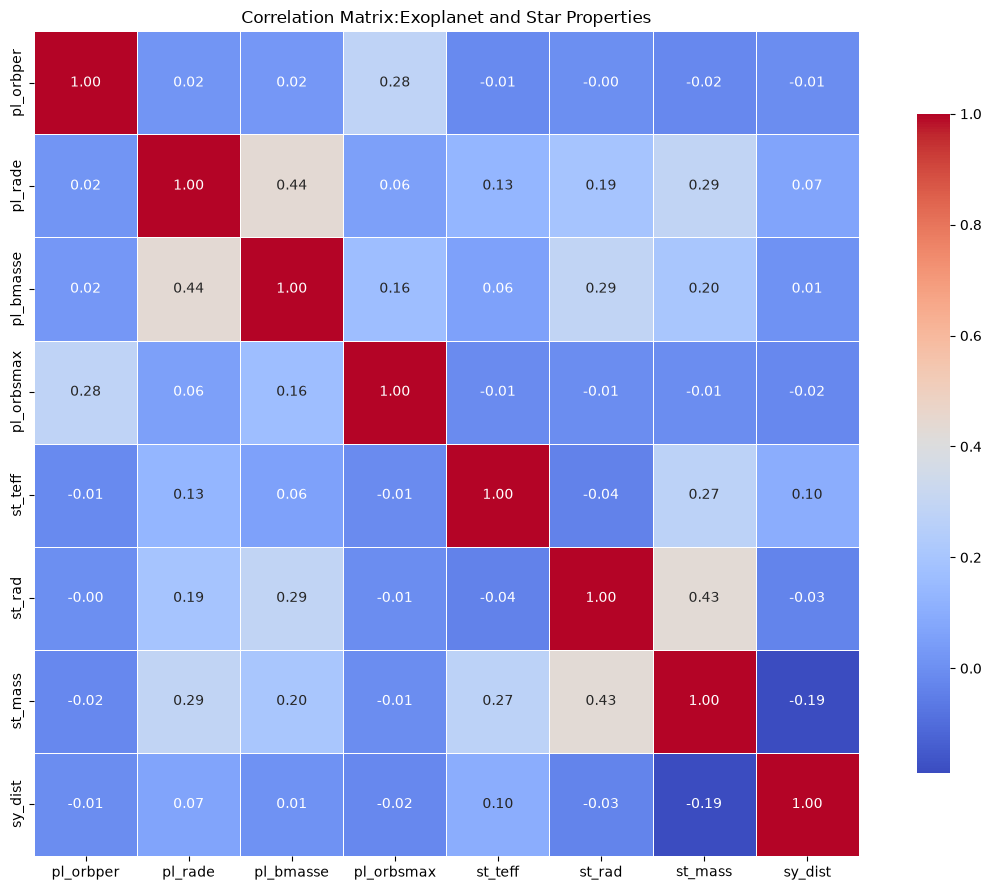

In [13]:
plt.figure(figsize=(12,9))

corr_cols = ['pl_orbper', 'pl_rade', 'pl_bmasse', 'pl_orbsmax', 'st_teff', 'st_rad', 'st_mass', 'sy_dist']
corr_cols = [c for c in corr_cols if c in df_clean.columns]
corr_matrix = df_clean[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix:Exoplanet and Star Properties')
plt.tight_layout()
plt.show()